In [38]:
import numpy as np
import pandas as pd
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Embedding, Flatten,Dropout
from tensorflow.keras.utils import to_categorical

In [39]:
train_ds = pd.read_csv('train.csv', encoding='latin-1')
validation_ds = pd.read_csv('test.csv', encoding='latin-1')


In [40]:

train_ds = train_ds[['text','sentiment']]
validation_ds = validation_ds[['text','sentiment']]

In [41]:
train_ds['text'] = train_ds['text'].fillna('')
validation_ds['text'] = validation_ds['text'].fillna('')

In [42]:
def func(sentiment):
    if sentiment =='positive':
        return 0
    elif sentiment =='negative':
        return 1
    else:
        return 2
train_ds['sentiment'] = train_ds['sentiment'].apply(func)
validation_ds['sentiment'] = validation_ds['sentiment'].apply(func)

In [43]:
x_train = np.array(train_ds['text'].tolist())
y_train = np.array(train_ds['sentiment'].tolist())
x_test = np.array(validation_ds['text'].tolist())
y_test = np.array(validation_ds['sentiment'].tolist())

In [44]:
x_train


array([' I`d have responded, if I were going',
       ' Sooo SAD I will miss you here in San Diego!!!',
       'my boss is bullying me...', ...,
       ' Yay good for both of you. Enjoy the break - you probably need it after such hectic weekend  Take care hun xxxx',
       ' But it was worth it  ****.',
       '   All this flirting going on - The ATG smiles. Yay.  ((hugs))'],
      shape=(27481,), dtype='<U159')

In [45]:
y_train


array([2, 1, 1, ..., 0, 0, 2], shape=(27481,))

In [46]:
y_train = to_categorical(y_train, 3)
y_test = to_categorical(y_test, 3)

In [47]:
tokenizer = Tokenizer(num_words=20000)


In [48]:
tokenizer.fit_on_texts(x_train)
tokenizer.fit_on_texts(x_test)

In [49]:
len(tokenizer.word_index)


28614

In [50]:
x_train = tokenizer.texts_to_sequences(x_train)
x_test = tokenizer.texts_to_sequences(x_test)

In [51]:
from keras.utils import pad_sequences
x_train = pad_sequences(x_train, padding='post', maxlen=35)  # Set maxlen to 35
x_test = pad_sequences(x_test, padding='post', maxlen=35)  

In [52]:
x_train[0]


array([   1,  162,   19, 7713,   71,    1,  151,   49,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0], dtype=int32)

In [53]:
x_train.shape


(27481, 35)

In [54]:
model = Sequential()
model.add(Embedding(input_dim=20000, output_dim=2, input_length=35))
model.add(SimpleRNN(32,return_sequences=False))
model.add(Dense(3,activation='softmax'))
model.summary()

c:\Users\sjai5\OneDrive\ドキュメント\deep_learning_toolbox\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [56]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10


859/859 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4662 - loss: 1.0333 - val_accuracy: 0.6463 - val_loss: 0.9102
Epoch 2/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5538 - loss: 0.9269 - val_accuracy: 0.6714 - val_loss: 0.8688
Epoch 3/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6130 - loss: 0.8574 - val_accuracy: 0.6820 - val_loss: 0.8451
Epoch 4/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6468 - loss: 0.8114 - val_accuracy: 0.6806 - val_loss: 0.8358
Epoch 5/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6820 - loss: 0.7610 - val_accuracy: 0.6793 - val_loss: 0.8491
Epoch 6/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7059 - loss: 0.7281 - val_accuracy: 0.6906 - val_loss: 0.8471
Epoch 7/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7189 - loss: 0.7050 - val_accuracy: 0.6897 - val_loss: 0.8262
Epoch 8/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7518 - loss: 0.6447 - val_accuracy: 0.6957 - val_

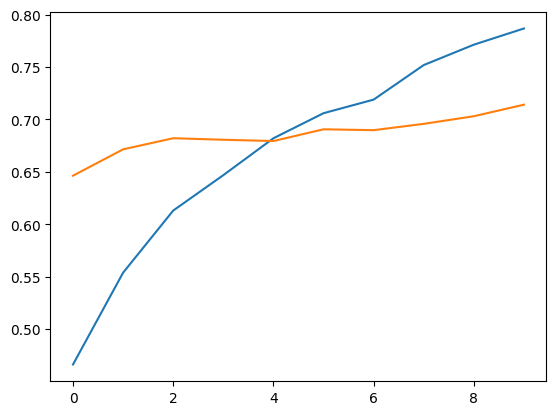

In [60]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()


In [61]:
# Prediction 1
text = "The movie was bad bad bad, i will not recommend this movie to anyone"

new_text_seq = tokenizer.texts_to_sequences([text])
new_text_padded = pad_sequences(new_text_seq, padding='post', maxlen=35)  # Use the max_len determined during training
predictions = model.predict(new_text_padded)
predicted_class_index = predictions.argmax(axis=-1)
if predicted_class_index[0] == 0:
    print("Postive Sentiment");
elif predicted_class_index[0] == 1:
    print("Negative Sentiment")
else:
    print("Neutral Sentiment")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Negative Sentiment


In [62]:
# Prediction 2

text = "The movie was good, i will recommend this movie to anyone"

new_text_seq = tokenizer.texts_to_sequences([text])
new_text_padded = pad_sequences(new_text_seq, padding='post', maxlen=35)  # Use the max_len determined during training
predictions = model.predict(new_text_padded)
predicted_class_index = predictions.argmax(axis=-1)
if predicted_class_index[0] == 0:
    print("Postive Sentiment");
elif predicted_class_index[0] == 1:
    print("Negative Sentiment")
else:
    print("Neutral Sentiment")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Postive Sentiment
